# Template

In [1]:
import pandas as pd
import polars as pl

import social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.assert_suffix_cols_equal import (
    join_equal_suffix_cols,
)
from social_groups.analysis.polars_transformations.deserialize_experiment_configuration import (
    deserialize_experiment_configuration,
)
from social_groups.analysis.polars_transformations.make_group_constellation import (
    parse_parameters,
)
from social_groups.analysis.polars_transformations.wasserstein_distance import (
    calculate_wasserstein_distance,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)
from social_groups.reporting.plots.changing_prompt.accuracy_change_by_group_constellation import (
    accuracy_change_by_group_constellation,
)
from social_groups.reporting.plots.changing_prompt.changed_prompt_vs_standard_prompt import (
    changed_prompt_vs_standard_prompt,
)
from social_groups.reporting.plots.changing_prompt.permutation_effect_within_each_model_family import (
    permutation_effect_within_each_model_family,
)

%load_ext autoreload
%autoreload 2

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:398: BetaWarning: Class `Manager` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  MANAGER_FOR_NOTEBOOK_INSTANCE = Manager()
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:180: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:185: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterth

In [2]:
parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling="wrong"
)

In [3]:
from social_groups.analysis.definitions import defs

changed_prompt_mad: pl.DataFrame = defs().load_asset_value("final_changed_prompt_mad")

medium_mad: pl.DataFrame = defs().load_asset_value(
    ["report", "final_medium_subset_mad", "medium_basic_mad_size_heterogeneity_result"]
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:101: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-06-20 21:01:31 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_changed_prompt_mad.parquet using PolarsParquetIOManager...
2026-06-20 21:01:31 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_medium_subset_mad/medium_basic_mad_size_heterogeneity_result.parquet using PolarsParquetIOManager...


In [4]:
NUM_ROUNDS = (
    changed_prompt_mad.with_columns(
        deserialize_experiment_configuration(pl.col("experiment_configuration_json"))
        .struct.field("strategy")
        .struct.field("configuration")
        .struct.field("number_of_rounds")
        .alias("number_of_rounds")
    )["number_of_rounds"]
    .unique()
    .item()
)

changed_prompt_mad = apply_parsing_and_group_decision(
    changed_prompt_mad, parser, comparer, group_reply
).drop(
    "message_ids",
    "run_identifier",
    "final_answer",
    "experiment_id",
    "experiment_configuration_json",
    "execution_config_json",
    "meta_info_json",
    "name",
    "data_connector",
)

In [5]:
changed_prompt_mad_result = (
    changed_prompt_mad.group_by("model_family", plc.group_constellation)
    .agg(
        pl.len(),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
        pl.col("model_names").unique().item(),
        (
            pl.col("___parsed_individual_answers_after___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_after___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_after"),
        (
            pl.col("___parsed_individual_answers_before___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_before___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_before"),
        comparer(
            pl.col(plc.parsed_combined_answers_before),
            pl.col(plc.answer_string),
        )
        .mean()
        .alias("accuracy_before"),
    )
    .sort(plc.accuracy, descending=True)
    .with_columns(
        pl.col("group_constellation").str.split("").list.sort().alias("sizes"),
        call_cost_heuristic=pl.col("model_names")
        .list.eval(parse_parameters(pl.element()) * 2 * NUM_ROUNDS)
        .list.sum(),
        accuracy_increase=pl.col("accuracy") - pl.col("accuracy_before"),
    )
    .with_columns(
        group_size=pl.col("group_constellation").str.len_chars(),
        is_homogeneous=pl.col("group_constellation")
        .str.split("")
        .list.unique()
        .list.len()
        == 1,
    )
)

changed_prompt_mad_result.sort("accuracy", descending=True).head()

model_family,group_constellation,len,accuracy,used_input_tokens,used_output_tokens,model_names,amount_parsing_errors_after,amount_parsing_errors_before,accuracy_before,sizes,call_cost_heuristic,accuracy_increase,group_size,is_homogeneous
str,str,u32,f64,f64,f64,list[str],f64,f64,f64,list[str],f64,f64,u32,bool
"""Qwen3""","""LHH""",300,0.816667,35238.273333,7875.943333,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.038889,0.097778,0.756667,"[""H"", ""H"", ""L""]",171.6,0.06,3,false
"""Qwen3.5""","""MLH""",300,0.8,74337.53,24287.976667,"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-9B""]",0.088889,0.177778,0.62,"[""H"", ""L"", ""M""]",82.8,0.18,3,false
"""Qwen3""","""HHM""",300,0.79,35793.576667,8369.896667,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-4B""]",0.016667,0.081111,0.75,"[""H"", ""H"", ""M""]",192.0,0.04,3,false
"""Qwen3.5""","""MMH""",300,0.78,87064.576667,29751.583333,"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B""]",0.118889,0.194444,0.68,"[""H"", ""M"", ""M""]",102.0,0.1,3,false
"""Qwen3.5""","""HHH""",300,0.78,88718.726667,31313.536667,"[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B""]",0.137778,0.194444,0.693333,"[""H"", ""H"", ""H""]",162.0,0.086667,3,true


In [6]:
merge_cols = ["model_family", "group_constellation"]


combined_results = join_equal_suffix_cols(
    changed_prompt_mad_result.select(
        *merge_cols, pl.exclude(merge_cols).name.suffix("_new_prompt")
    ).join(
        medium_mad.filter(pl.col("group_size").is_in({2, 3})),
        on=merge_cols,
        how="left",
        validate="1:1",
    ),
    "_right",
)

combined_results.head()

model_family,group_constellation,len_new_prompt,accuracy_new_prompt,used_input_tokens_new_prompt,used_output_tokens_new_prompt,model_names_new_prompt,amount_parsing_errors_after_new_prompt,amount_parsing_errors_before_new_prompt,accuracy_before_new_prompt,sizes_new_prompt,call_cost_heuristic_new_prompt,accuracy_increase_new_prompt,group_size_new_prompt,is_homogeneous_new_prompt,run_id,message_ids,run_identifier,final_answer,experiment_id,experiment_configuration_json,execution_config_json,meta_info_json,name,data_connector,model_names,wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False,accuracy,accuracy_before,accuracy_increase,accuracy_increase_percent,group_size,is_homogeneous,used_output_tokens,sizes,used_input_tokens,amount_parsing_errors_before,len,call_cost_heuristic,amount_parsing_errors_after
str,str,u32,f64,f64,f64,list[str],f64,f64,f64,list[str],f64,f64,u32,bool,i64,list[null],str,null,i64,str,str,str,str,str,list[str],f64,f64,f64,f64,f64,f64,f64,f64,u32,bool,f64,list[str],f64,f64,u32,f64,f64
"""Qwen3""","""LHH""",300,0.816667,35238.273333,7875.943333,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.038889,0.097778,0.756667,"[""H"", ""H"", ""L""]",171.6,0.06,3,false,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Qwen3.5""","""MLH""",300,0.8,74337.53,24287.976667,"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-9B""]",0.088889,0.177778,0.62,"[""H"", ""L"", ""M""]",82.8,0.18,3,false,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Qwen3""","""HHM""",300,0.79,35793.576667,8369.896667,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-4B""]",0.016667,0.081111,0.75,"[""H"", ""H"", ""M""]",192.0,0.04,3,false,933,[],"""2026-06-06-19-52-59 - heteroge…",null,16,"""{""name"":""heterogeneous_group_m…","""{""num_workers"":20,""phoenix_gra…","""{""execution"":{""started_at_utc""…","""heterogeneous_group_mad3""","""mmlu-pro-medium-subset""","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-4B""]",0.199435,0.40139,0.32034,0.300413,0.76,0.74,0.02,0.027027,3,false,8431.14,"[""H"", ""H"", ""M""]",35499.413333,0.08,300,192.0,0.018889
"""Qwen3.5""","""MMH""",300,0.78,87064.576667,29751.583333,"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B""]",0.118889,0.194444,0.68,"[""H"", ""M"", ""M""]",102.0,0.1,3,false,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Qwen3.5""","""HHH""",300,0.78,88718.726667,31313.536667,"[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B""]",0.137778,0.194444,0.693333,"[""H"", ""H"", ""H""]",162.0,0.086667,3,true,924,[],"""2026-04-24-12-20-34 - heteroge…",null,16,"""{""name"":""heterogeneous_group_m…","""{""num_workers"":20,""phoenix_gra…","""{""execution"":{""started_at_utc""…","""heterogeneous_group_mad3""","""mmlu-pro-medium-subset""","[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B""]",0.269264,0.43368,0.442651,0.351472,0.706667,0.713333,-0.006667,-0.009346,3,true,29619.686667,"[""H"", ""H"", ""H""]",83037.41,0.166667,300,162.0,0.174444


In [7]:
changed_prompt_mad_wd = (
    calculate_wasserstein_distance(changed_prompt_mad, group_reply, comparer, "run_id")
    .drop("run_id")
    .with_columns(
        group_size=pl.col("group_constellation").str.len_chars(),
        is_homogeneous=pl.col("group_constellation")
        .str.split("")
        .list.unique()
        .list.len()
        == 1,
    )
    .select(*merge_cols, pl.exclude(merge_cols).name.suffix("_new_prompt"))
    .drop("accuracy_increase_percent_new_prompt")
)

combined_results_with_wd = combined_results.join(
    changed_prompt_mad_wd,
    on=([x for x in changed_prompt_mad_wd.columns if not x.startswith("wd")]),
    how="full",
    validate="1:1",
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_changing_prompt/changed_prompt_vs_standard_prompt.png


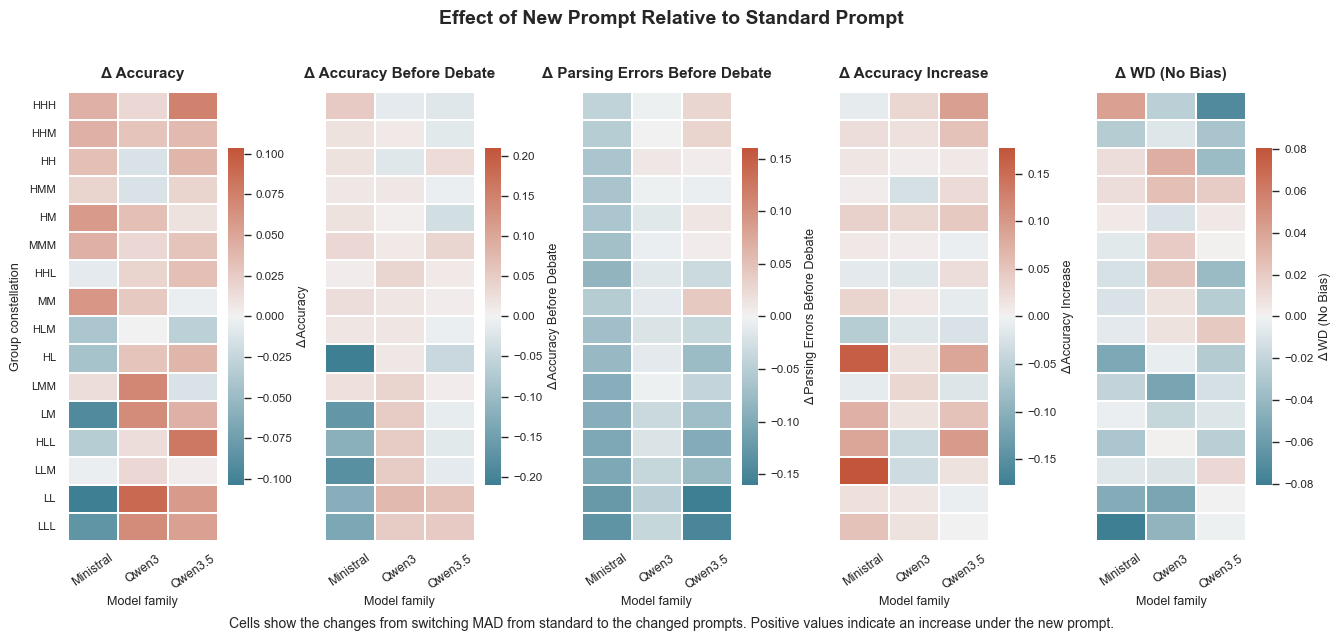

In [8]:
register_materialization(
    "changed_prompt_vs_standard_prompt",
    changed_prompt_vs_standard_prompt(combined_results_with_wd),
    "Effect of sing the new prompt against the original MAD prompt for differenct metrics",
    force=True,
)

 Views:
- Change in Wasserstein Distance, group-increase, accuracy pre and post (to show if the prompt is better initially or better in making the debate good)
- See the impact achieved with changing order
- - influence on parsing error

In [9]:
only_changed_prompt = join_equal_suffix_cols(
    combined_results_with_wd.drop(
        [
            col
            for col, count in zip(
                combined_results_with_wd.columns,
                combined_results_with_wd.null_count().row(0),
            )
            if count > 0
        ]
    ),
    "_right",
).select(
    "model_family",
    "group_constellation",
    pl.selectors.ends_with("_new_prompt").name.replace("_new_prompt", ""),
)

only_changed_prompt.schema

Schema([('model_family', String),
        ('group_constellation', String),
        ('len', UInt32),
        ('accuracy', Float64),
        ('used_input_tokens', Float64),
        ('used_output_tokens', Float64),
        ('model_names', List(String)),
        ('amount_parsing_errors_after', Float64),
        ('amount_parsing_errors_before', Float64),
        ('accuracy_before', Float64),
        ('sizes', List(String)),
        ('call_cost_heuristic', Float64),
        ('accuracy_increase', Float64),
        ('group_size', UInt32),
        ('is_homogeneous', Boolean),
        ('wd_bias_good proposals', Float64),
        ('wd_bias_bad proposals', Float64),
        ('wd_bias_weight on one', Float64),
        ('wd_bias_False', Float64)])

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_changing_prompt/accuracy_change_by_group_constellation.png


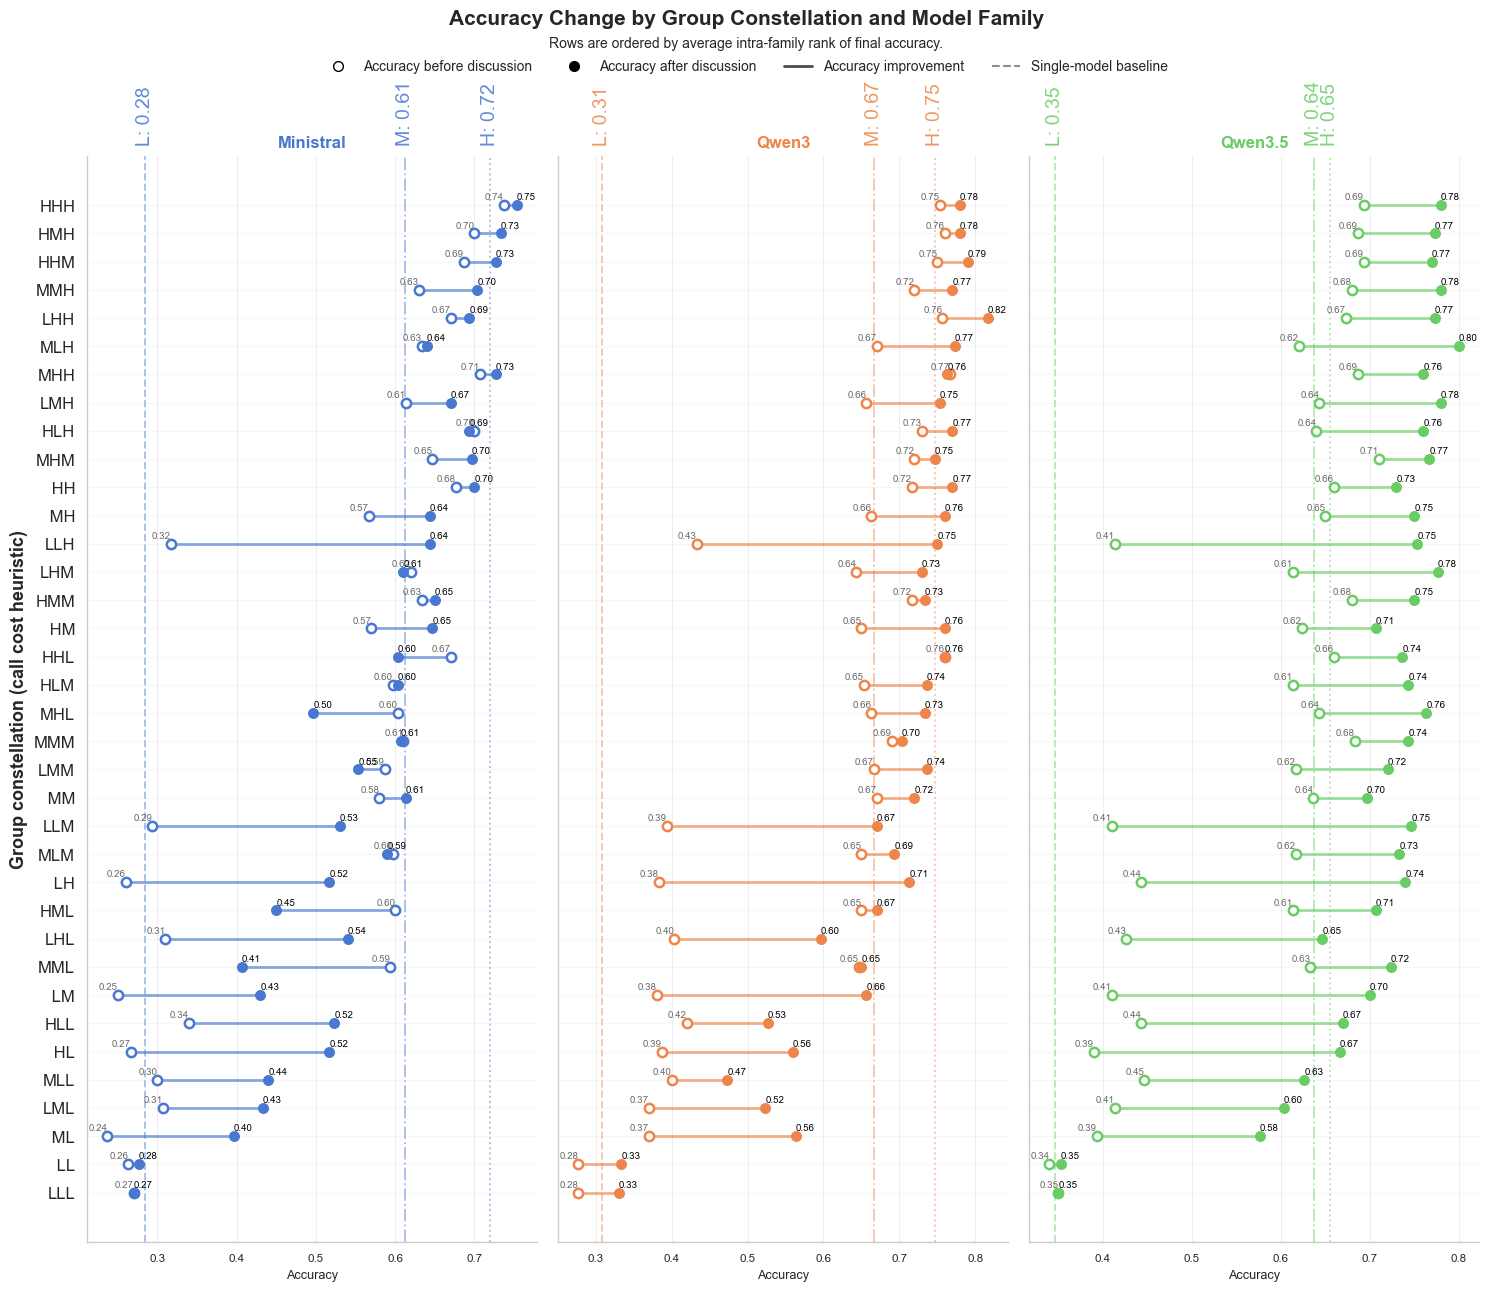

In [14]:
register_materialization(
    "accuracy_change_by_group_constellation",
    accuracy_change_by_group_constellation(changed_prompt_mad, only_changed_prompt),
    "Change in accuracy by group constellation compared to single-model baselines sorted by cost call heuristic.",
    force=True,
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_changing_prompt/permutation_effect_within_each_model_family.png


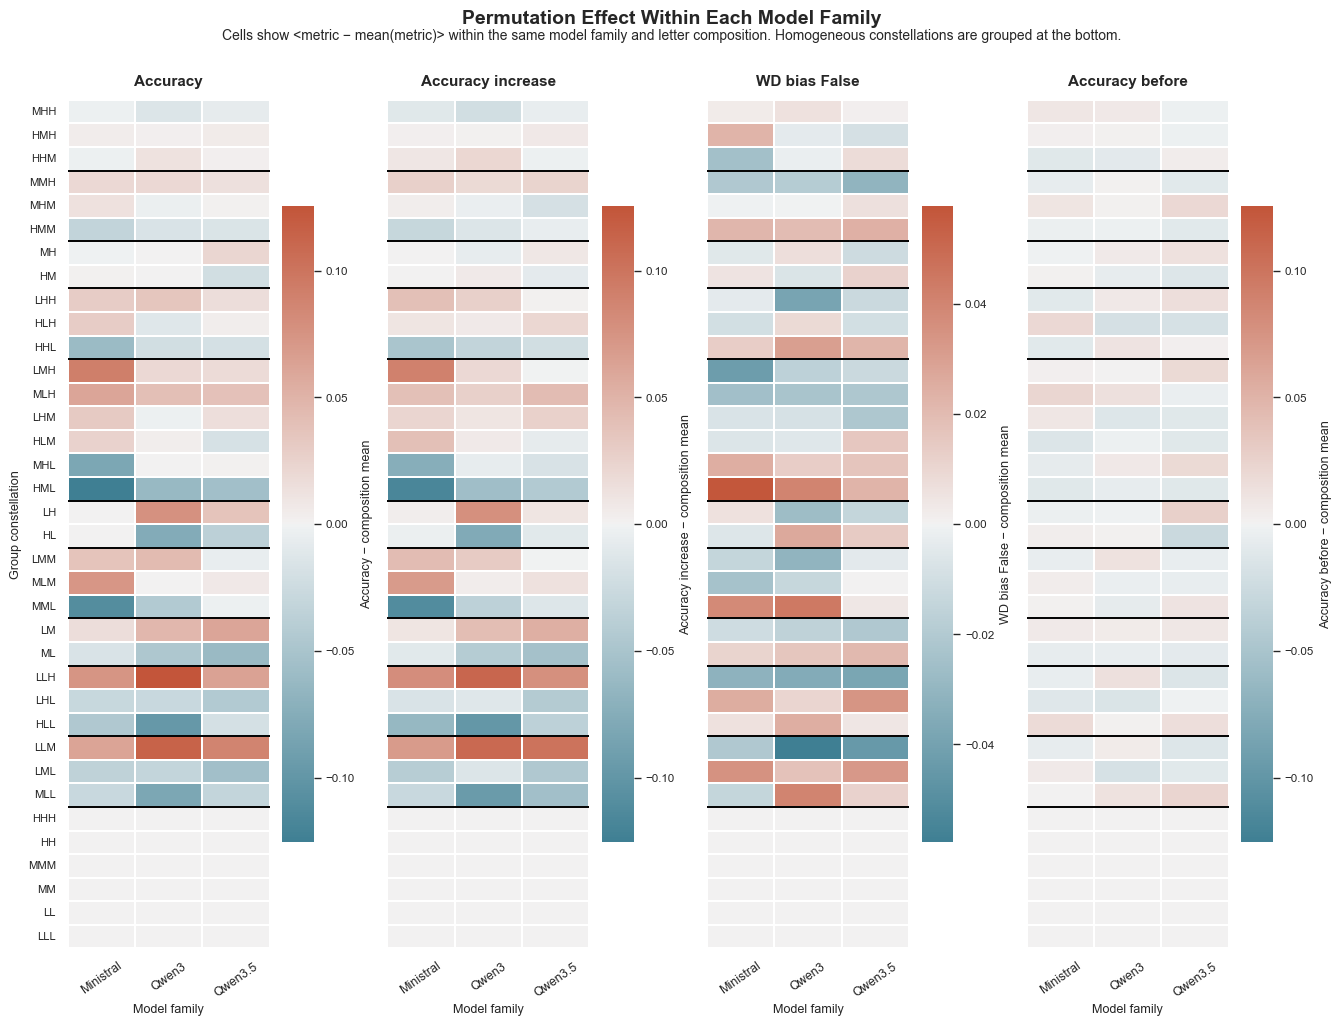

In [16]:
register_materialization(
    "permutation_effect_within_each_model_family",
    permutation_effect_within_each_model_family(only_changed_prompt),
    "Permutation Effect within each model Family, for changing the group order",
    force=True,
)

In [58]:
import polars as pl


def add_group_metric(
    df: pl.DataFrame,
    values_col: str,
    group_cols: list[str],
    metric_col: str = "metric",
) -> pl.DataFrame:
    tmp_id = "__row_id"

    base = df.with_row_index(tmp_id)

    long = (
        base.select([tmp_id, *group_cols, values_col])
        .explode(values_col)
        .with_columns(
            value=pl.col(values_col).cast(pl.Float64),
            pos=(pl.col(values_col).cum_count().over(tmp_id) - 1),
        )
        .with_columns(group_max=pl.col("value").max().over(group_cols))
        .with_columns(
            digit=(
                pl.when(pl.col("group_max") > 0)
                .then((pl.col("value") / pl.col("group_max") * 10).round())
                .otherwise(0)
                .clip(1, 10)
                .cast(pl.Int64)
            )
        )
    )

    metrics = (
        long.group_by(tmp_id, maintain_order=True)
        .agg(pl.col("digit").sort_by("pos").alias("__digits"))
        .with_columns(
            pl.col("__digits")
            .list.reverse()
            .list.eval(pl.element().cast(pl.Utf8).str.zfill(2))
            .list.join("")
            .cast(pl.Int64)
            .alias(metric_col)
        )
        .select([tmp_id, metric_col])
    )

    return base.join(metrics, on=tmp_id, how="left").drop(tmp_id)


import polars as pl


def add_rank_metric(
    df: pl.DataFrame,
    values_col: str,
    group_cols: list[str],
    metric_col: str = "rank_metric",
) -> pl.DataFrame:
    tmp_id = "__row_id"

    base = df.with_row_index(tmp_id)

    long = (
        base.select([tmp_id, *group_cols, values_col])
        .explode(values_col)
        .with_columns(
            value=pl.col(values_col).cast(pl.Float64),
            pos=(pl.col(values_col).cum_count().over(tmp_id) - 1),
        )
        .with_columns(
            # dense rank within each comparable subgroup
            rank=(pl.col("value").rank(method="dense").over(group_cols).cast(pl.Int64))
        )
    )

    metrics = (
        long.group_by(tmp_id, maintain_order=True)
        .agg(pl.col("rank").sort_by("pos").alias("__ranks"))
        .with_columns(
            pl.col("__ranks")
            .map_elements(
                lambda xs: xs[::-1] if len(xs) == 2 else [xs[2], xs[0], xs[1]],
                return_dtype=pl.List(pl.Int64),
            )
            .list.eval(pl.element().cast(pl.Utf8))
            .list.join("")
            .cast(pl.Int64)
            .alias(metric_col)
        )
        .select([tmp_id, metric_col])
    )

    return base.join(metrics, on=tmp_id, how="left").drop(tmp_id)


metrics = (
    add_rank_metric(
        add_group_metric(
            only_changed_prompt.select(
                "group_constellation",
                "accuracy",
                pl.col("model_names")
                .list.eval(parse_parameters(pl.element()))
                .alias("params"),
                "model_family",
                "group_size",
            )
            .with_columns(
                pl.col("params")
                .list.eval(
                    (pl.element() * 10).cast(pl.Int64).cast(pl.Utf8).str.zfill(4)
                )
                .list.reverse()
                .list.join("")
                .cast(pl.Int64)
                .alias("four-digit-params_metric"),
                pl.col("group_constellation")
                .str.count_matches("H")
                .alias("high-ability-members_metric"),
            )
            .with_columns(
                accuracy_rank=(
                    pl.col("accuracy")
                    .rank(method="average", descending=True)
                    .over(["model_family", "group_size"])
                )
            )
            .group_by(pl.exclude("accuracy_rank"))
            .agg(
                pl.col("accuracy_rank").mean().alias("avg_rank_metric"),
            ),
            values_col="params",
            group_cols=["model_family"],
            metric_col="norm_metric",
        ),
        values_col="params",
        group_cols=["model_family"],
        metric_col="rank_metric",
    ).with_columns(participants=pl.col("group_constellation").str.split(""))
    # .group_by("model_family", "group_size")
    # .agg(
    #     pl.corr(pl.selectors.ends_with("_metric"), "accuracy", method="spearman").name.replace("_metric", "_spearman_corr"),
    # )
    # .rename(
    #     {
    #         "model_family": "Model Family",
    #         "group_size": "Group Size",
    #     }
    # )
)
metrics

group_constellation,accuracy,params,model_family,group_size,four-digit-params_metric,high-ability-members_metric,avg_rank_metric,norm_metric,rank_metric,participants
str,f64,list[f64],str,u32,i64,u32,f64,i64,i64,list[str]
"""HML""",0.67,"[14.0, 4.0, 0.6]","""Qwen3""",3,600400140,1,20.5,10310,132,"[""H"", ""M"", ""L""]"
"""LHL""",0.54,"[3.0, 14.0, 3.0]","""Ministral""",3,3001400030,1,19.0,21002,113,"[""L"", ""H"", ""L""]"
"""LHH""",0.773333,"[0.8, 9.0, 9.0]","""Qwen3.5""",3,9000900008,2,6.5,101001,313,"[""L"", ""H"", ""H""]"
"""LLH""",0.75,"[0.6, 0.6, 14.0]","""Qwen3""",3,14000060006,1,11.0,100101,311,"[""L"", ""L"", ""H""]"
"""HLL""",0.526667,"[14.0, 0.6, 0.6]","""Qwen3""",3,600060140,1,24.0,10110,131,"[""H"", ""L"", ""L""]"
…,…,…,…,…,…,…,…,…,…,…
"""MLM""",0.693333,"[4.0, 0.6, 4.0]","""Qwen3""",3,4000060040,0,19.0,30103,221,"[""M"", ""L"", ""M""]"
"""LHM""",0.776667,"[0.8, 9.0, 4.0]","""Qwen3.5""",3,4000900008,1,5.0,41001,213,"[""L"", ""H"", ""M""]"
"""MM""",0.613333,"[8.0, 8.0]","""Ministral""",2,800080,0,4.0,606,22,"[""M"", ""M""]"


In [74]:
import polars as pl
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.pipeline import Pipeline


def fit_participant_tree(
    df: pl.DataFrame,
    target_col: str = "avg_rank_metric",
    participants_col: str = "participants",
    max_depth: int = 4,
    min_samples_leaf: int = 5,
):
    max_len = df.select(pl.col(participants_col).list.len().max()).item()

    # turn participants = ["A", "B", "C"]
    # into p0="A", p1="B", p2="C"
    wide = df.with_columns([
        pl.col(participants_col).list.get(i, null_on_oob=True).alias(["first", "middle", "last"][i])
        for i in range(max_len)
    ])

    feature_cols = [["first", "middle", "last"][i] for i in range(max_len)]

    pdf = wide.select([*feature_cols, target_col]).drop_nulls(target_col).to_pandas()

    X = pdf[feature_cols]
    y = pdf[target_col]

    preprocessor = ColumnTransformer(
        transformers=[
            ("participants", OneHotEncoder(handle_unknown="ignore"), feature_cols)
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    tree = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=0,
    )

    model = Pipeline([
        ("onehot", preprocessor),
        ("tree", tree),
    ])

    model.fit(X, y)

    feature_names = model.named_steps["onehot"].get_feature_names_out()

    print(
        export_text(
            model.named_steps["tree"],
            feature_names=list(feature_names),
            decimals=3,
        ).replace("<= 0.500", "not").replace(">  0.500", "")
    )

    return model, wide

model, tree_data = fit_participant_tree(
    metrics.filter(group_size=3),
    target_col="avg_rank_metric",
    participants_col="participants",
    max_depth=4,
    min_samples_leaf=1,
)

|--- last_L not
|   |--- last_H not
|   |   |--- middle_H not
|   |   |   |--- first_H not
|   |   |   |   |--- value: [17.625]
|   |   |   |--- first_H 
|   |   |   |   |--- value: [14.167]
|   |   |--- middle_H 
|   |   |   |--- first_H not
|   |   |   |   |--- value: [10.333]
|   |   |   |--- first_H 
|   |   |   |   |--- value: [4.500]
|   |--- last_H 
|   |   |--- middle_L not
|   |   |   |--- first_H not
|   |   |   |   |--- value: [6.208]
|   |   |   |--- first_H 
|   |   |   |   |--- value: [3.250]
|   |   |--- middle_L 
|   |   |   |--- first_L not
|   |   |   |   |--- value: [7.250]
|   |   |   |--- first_L 
|   |   |   |   |--- value: [11.667]
|--- last_L 
|   |--- middle_H not
|   |   |--- first_L not
|   |   |   |--- middle_M not
|   |   |   |   |--- value: [23.833]
|   |   |   |--- middle_M 
|   |   |   |   |--- value: [22.250]
|   |   |--- first_L 
|   |   |   |--- middle_L not
|   |   |   |   |--- value: [25.333]
|   |   |   |--- middle_L 
|   |   |   |   |--- value: [2

- show changes in accuracy before and incrtease and after as a combination
- compare if with parsing errors before and after

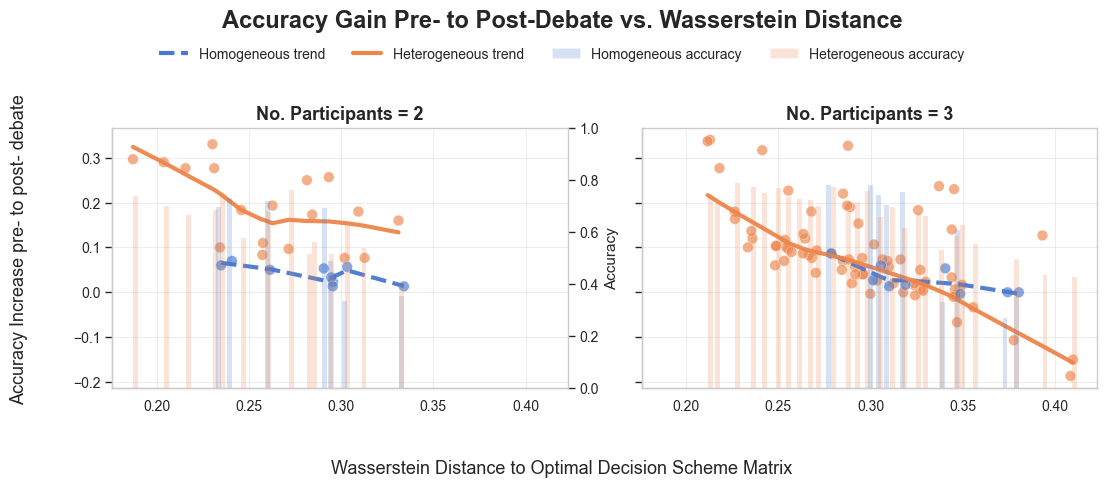

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", context="paper", palette="muted", font_scale=1.15)

plot_df = (
    changed_prompt_mad_wd.select(pl.all().name.replace("_new_prompt", ""))
    .with_columns(
        group_size=pl.col("group_constellation").str.len_chars(),
        is_homogeneous=pl.col("group_constellation")
        .str.split("")
        .list.unique()
        .list.len()
        == 1,
    )
    .sort("group_size", "is_homogeneous")
    .to_pandas()
)

plot_df["Homogeneity"] = plot_df["is_homogeneous"].map(
    {
        True: "Homogeneous",
        False: "Heterogeneous",
    }
)
plot_df["Group size"] = plot_df["group_size"].astype(int)

homogeneity_palette = {
    "Homogeneous": sns.color_palette("muted")[0],
    "Heterogeneous": sns.color_palette("muted")[1],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

n_bins = 35
x_min = plot_df["wd_bias_False"].min()
x_max = plot_df["wd_bias_False"].max()
bins = np.linspace(x_min, x_max, n_bins + 1)
bin_width = bins[1] - bins[0]

bar_axes = []

for ax, group_size in zip(axes, [2, 3]):
    subset_g = plot_df[plot_df["Group size"] == group_size]

    # Secondary y-axis for accuracy bars
    ax_bar = ax.twinx()
    bar_axes.append(ax_bar)

    for i, (homogeneity, color) in enumerate(homogeneity_palette.items()):
        subset_h = subset_g[subset_g["Homogeneity"] == homogeneity].copy()

        if subset_h.empty:
            continue

        subset_h["wd_bin"] = pd.cut(
            subset_h["wd_bias_False"],
            bins=bins,
            include_lowest=True,
        )

        bar_df = (
            subset_h.groupby("wd_bin", observed=True)
            .agg(
                accuracy=("accuracy", "mean"),
                x=("wd_bias_False", "mean"),
            )
            .dropna()
            .reset_index()
        )

        offset = (-0.22 if homogeneity == "Homogeneous" else 0.22) * bin_width

        ax_bar.bar(
            bar_df["x"] + offset,
            bar_df["accuracy"],
            width=0.42 * bin_width,
            color=color,
            alpha=0.22,
            edgecolor="none",
            zorder=0,
        )

    ax_bar.set_ylim(0, 1)
    ax_bar.grid(False)
    ax_bar.set_ylabel("")

    # Only right column gets secondary y-label/ticks
    if group_size in [2, 4]:
        ax_bar.set_ylabel("Accuracy", fontsize=11)
    else:
        ax_bar.set_yticklabels([])
        ax_bar.tick_params(axis="y", length=0)

    # Scatter
    sns.scatterplot(
        data=subset_g,
        x="wd_bias_False",
        y="accuracy_increase",
        hue="Homogeneity",
        palette=homogeneity_palette,
        alpha=0.65,
        s=60,
        edgecolor="white",
        linewidth=0.4,
        legend=False,
        ax=ax,
        zorder=3,
    )

    # LOWESS trend lines
    for homogeneity, linestyle in [
        ("Homogeneous", "--"),
        ("Heterogeneous", "-"),
    ]:
        subset = subset_g[subset_g["Homogeneity"] == homogeneity]

        if len(subset) < 5:
            continue

        sns.regplot(
            data=subset,
            x="wd_bias_False",
            y="accuracy_increase",
            scatter=False,
            lowess=True,
            color=homogeneity_palette[homogeneity],
            ci=95,
            line_kws={
                "linewidth": 3,
                "linestyle": linestyle,
                "alpha": 0.95,
                "zorder": 4,
            },
            ax=ax,
        )

    ax.set_title(f"No. Participants = {group_size}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.supxlabel(
    "Wasserstein Distance to Optimal Decision Scheme Matrix",
    fontsize=13,
    y=0.045,
)

fig.supylabel(
    "Accuracy Increase pre- to post- debate",
    fontsize=13,
    x=0.04,
)

fig.suptitle(
    "Accuracy Gain Pre- to Post-Debate vs. Wasserstein Distance",
    fontsize=17,
    fontweight="bold",
    y=0.98,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=homogeneity_palette["Homogeneous"],
        lw=3,
        linestyle="--",
        label="Homogeneous trend",
    ),
    Line2D(
        [0],
        [0],
        color=homogeneity_palette["Heterogeneous"],
        lw=3,
        linestyle="-",
        label="Heterogeneous trend",
    ),
    Patch(
        facecolor=homogeneity_palette["Homogeneous"],
        alpha=0.22,
        label="Homogeneous accuracy",
    ),
    Patch(
        facecolor=homogeneity_palette["Heterogeneous"],
        alpha=0.22,
        label="Heterogeneous accuracy",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0.05, 0.07, 0.96, 0.90])